### APS1070 Project 3 - Part 1, Git Practice

**Academic Integrity**

This project is individual - it is to be completed on your own. If you have questions, please post your query in the APS1070 Piazza Q&A forums (the answer might be useful to others!).

Do not share your code with others, or post your work online. Do not submit code that you have not written yourself. Students suspected of plagiarism on a project, midterm or exam will be referred to the department for formal discipline for breaches of the Student Code of Conduct.

Please fill out the following:


*   Your **name**: Terry Wong
*   Your **student number**: 1012858301



## Part 1: Getting started with GitHub [1.5 Marks + 2 Mark Git Submission]


For the first four parts (Part 1-4) of this project, we will work on a [population of countries dataset](https://ourworldindata.org/grapher/population) which reports the population of over 200 countries worldwide from 10000 BCE to 2023. Download the dataset in .csv format using the provided code below. Using the Pandas package, create a population dataframe with only the countries provided in [this GitHub list](https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt) (237 countries - you should remove all other entities) as rows and years from 1901 to 2023 (123 years) as columns. Then, remove all the countries that have at least missing or invalid value over the years.

In [7]:
import pandas as pd
import requests, io

headers = {"User-Agent": "Mozilla/5.0"}
raw_data = pd.read_csv(
    filepath_or_buffer=io.StringIO(requests.get(
        'https://ourworldindata.org/grapher/population.csv?v=1&csvType=full&useColumnShortNames=true',
        headers=headers).text),
    index_col=False)

countries_list_url = "https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt"

In [8]:
print(raw_data.columns)

Index(['entity', 'code', 'year', 'population_historical'], dtype='object')


In [9]:
### YOUR CODE HERE ###
countries_text = requests.get(countries_list_url,headers=headers).text

countries = [
    country.strip()
    for country in countries_text.splitlines()
    if country.strip()
]

population = raw_data[raw_data["entity"].isin(countries) &raw_data["year"].between(1901, 2023)].copy()

population = population.pivot(index="entity",columns="year",values="population_historical")

population = population.reindex(columns=range(1901, 2024))
population = population.apply(pd.to_numeric, errors="coerce")
population = population.dropna(axis=0)

print("Final shape:", population.shape)
display(population.head())

Final shape: (196, 123)


year,1901,1902,1903,1904,1905,1906,1907,1908,1909,1910,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
entity,,,,,,,,,,,,,,,,,,,,,
Afghanistan,4751177.0,4802500.0,4861833.0,4921891.0,4982681.0,5044212.0,5106495.0,5169536.0,5300178.0,5504191.0,...,32792528.0,33831767.0,34700613.0,35688941.0,36743040.0,37856125.0,39068977.0,40000410.0,40578847.0,41454762.0
Albania,813539.0,821036.0,828461.0,835954.0,843514.0,851143.0,858841.0,866609.0,874016.0,881057.0,...,2903748.0,2898634.0,2897868.0,2898245.0,2894229.0,2885011.0,2871950.0,2849641.0,2827614.0,2811660.0
Algeria,4787149.0,4859600.0,4939332.0,5020372.0,5102742.0,5186463.0,5271557.0,5358048.0,5433528.0,5497750.0,...,39205035.0,40019528.0,40850719.0,41689302.0,42505033.0,43294551.0,44042094.0,44761099.0,45477391.0,46164222.0
Andorra,4551.0,4581.0,4610.0,4640.0,4670.0,4700.0,4730.0,4761.0,4802.0,4855.0,...,73755.0,72195.0,72197.0,73780.0,75181.0,76492.0,77397.0,78379.0,79722.0,80869.0
Angola,3083888.0,3064493.0,3043335.0,3022320.0,3001447.0,2980714.0,2960121.0,2939666.0,2921666.0,2906100.0,...,27160767.0,28157802.0,29183072.0,30234836.0,31297160.0,32375633.0,33451139.0,34532427.0,35635028.0,36749909.0


1. Write a function to do the following: **[0.5]**
    * Takes the dataframe, and your list of countries/regions as inputs (Afghanistan, Albania, Algeria, ...)
    * Plots time-series for the input list (it is best to plot each country in a separate graph (subplot), so you can easily compare them.)
    
2. Apply `StandardScalar` to the data. Each year should have a `mean` of zero and a `StD` of 1. **[0.25]**
3. Pick two countries whose names are closest to your first name using string edit distance.
Hint: you can use `Levenshtein.distance()` from the python-Levenshtein package. You may find [this link](https://www.geeksforgeeks.org/python/introduction-to-python-levenshtein-module/) helpful.
4. Run the function in `step 1` on both the original as well as the standardized dataset for the two countries you picked in `step 3` plus `Japan`, `Bosnia and Herzegovina`, `Latvia`, and `United Arab Emirates`. (If you have already selected one of these countries, go down the list and pick the next one you haven't selected) **[0.25]**
5. Discuss the trends in the standardized time-series for all these countries. What does it mean if the curve goes up or down? What does the sign of values indicate? **[0.5]**

**Japan: Increased until around 1950, then declined.
Bosnia and Herzegovina: Stayed below average and generally declined relative to other countries.
Latvia: Stayed below average with a slight recovery around the 1960s–1970s before declining again.
United Arab Emirates: Increased rapidly after 1960, becoming closer to the average, but remained below it.
Upward curve: Population is increasing relative to other countries.
Downward curve: Population is decreasing relative to other countries.
Positive values: Above the yearly average population.
Negative values: Below the yearly average population.
Value near 0: Close to the yearly average population.**

In [10]:
!pip install python-Levenshtein

In [11]:
### YOUR CODE HERE ###
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import Levenshtein

def plot_countries(df, country_list):
    fig, axes = plt.subplots(
        len(country_list), 1,
        figsize=(10, 3 * len(country_list))
    )

    # Makes axes iterable when only one country is provided
    if len(country_list) == 1:
        axes = [axes]

    for ax, country in zip(axes, country_list):
        ax.plot(df.columns, df.loc[country])
        ax.set_title(country)
        ax.set_xlabel("Year")
        ax.set_ylabel("Population")
        ax.grid()

    plt.tight_layout()
    plt.show()

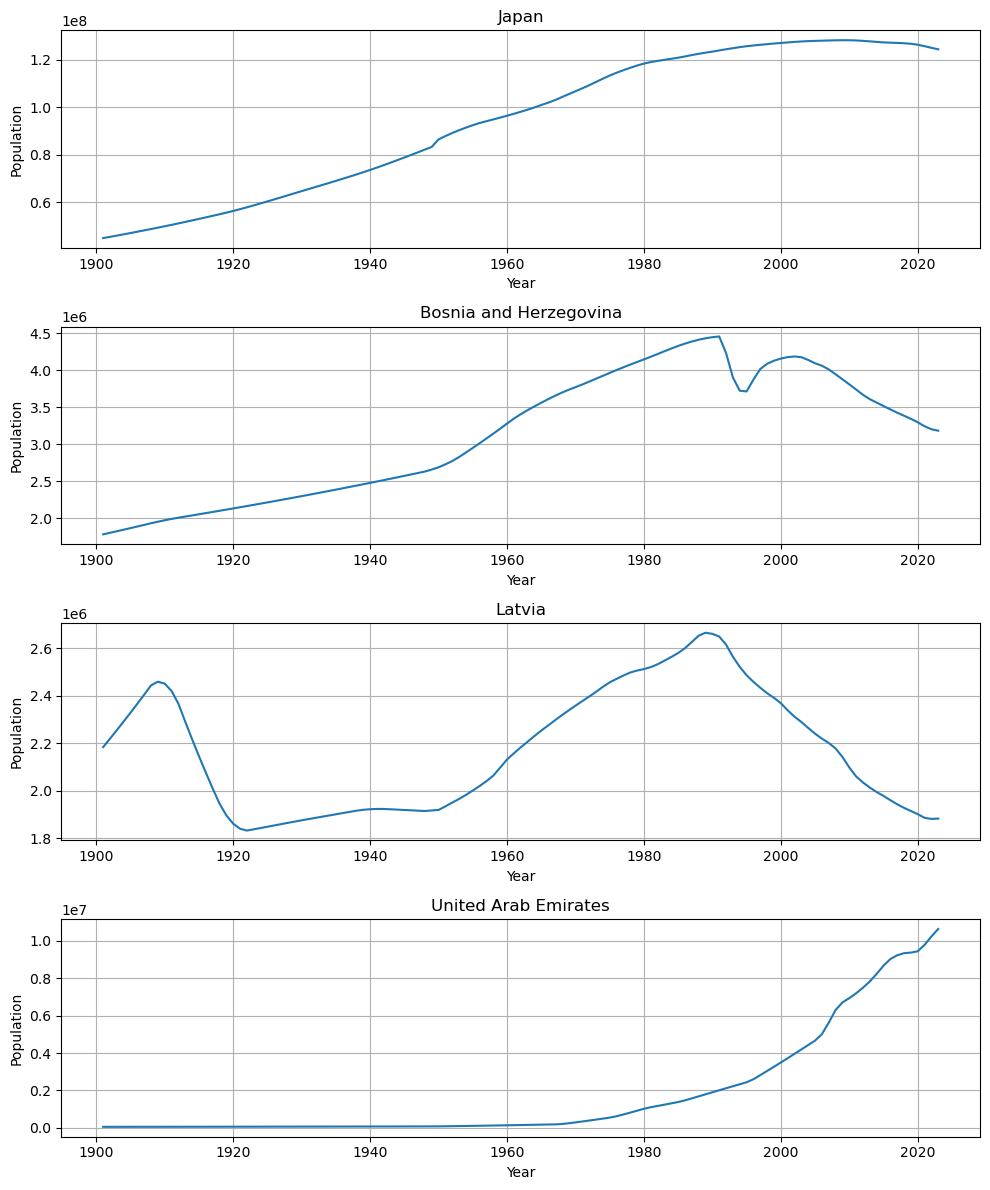

In [14]:
countries_to_plot = ["Japan","Bosnia and Herzegovina","Latvia","United Arab Emirates"]

plot_countries(population, countries_to_plot)

In [19]:
scaler = StandardScaler()

population_standardized = pd.DataFrame(scaler.fit_transform(population),index=population.index,columns=population.columns)

display(population_standardized.head())

year,1901,1902,1903,1904,1905,1906,1907,1908,1909,1910,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
entity,,,,,,,,,,,,,,,,,,,,,
Afghanistan,-0.100165,-0.100047,-0.099763,-0.099484,-0.099208,-0.098936,-0.098672,-0.098414,-0.096248,-0.092059,...,-0.034059,-0.029623,-0.026427,-0.022423,-0.017953,-0.013063,-0.007375,-0.003373,-0.001763,0.001713
Albania,-0.210133,-0.210609,-0.211095,-0.211588,-0.212088,-0.212596,-0.213114,-0.213642,-0.214023,-0.214260,...,-0.246648,-0.247677,-0.248635,-0.249513,-0.250503,-0.251641,-0.252834,-0.254159,-0.255592,-0.257056
Algeria,-0.099160,-0.098461,-0.097624,-0.096782,-0.095934,-0.095080,-0.094224,-0.093365,-0.092700,-0.092229,...,0.011552,0.013996,0.016545,0.019132,0.021633,0.024039,0.026348,0.028763,0.031174,0.033249
Andorra,-0.232726,-0.233281,-0.233835,-0.234396,-0.234965,-0.235540,-0.236126,-0.236721,-0.237152,-0.237421,...,-0.266777,-0.267602,-0.268379,-0.269074,-0.269870,-0.270801,-0.271785,-0.272866,-0.274068,-0.275342
Angola,-0.146728,-0.148310,-0.149959,-0.151601,-0.153239,-0.154871,-0.156500,-0.158127,-0.159538,-0.160733,...,-0.074116,-0.069620,-0.064978,-0.060195,-0.055368,-0.050451,-0.045471,-0.040285,-0.035004,-0.029793


In [22]:
first_name = "Wong"

distances = {country: Levenshtein.distance(first_name.lower(),country.lower())
    for country in population.index
}

closest_countries = sorted(distances,key=distances.get)[:2]

print("Closest countries:", closest_countries)

Closest countries: ['Congo', 'Tonga']


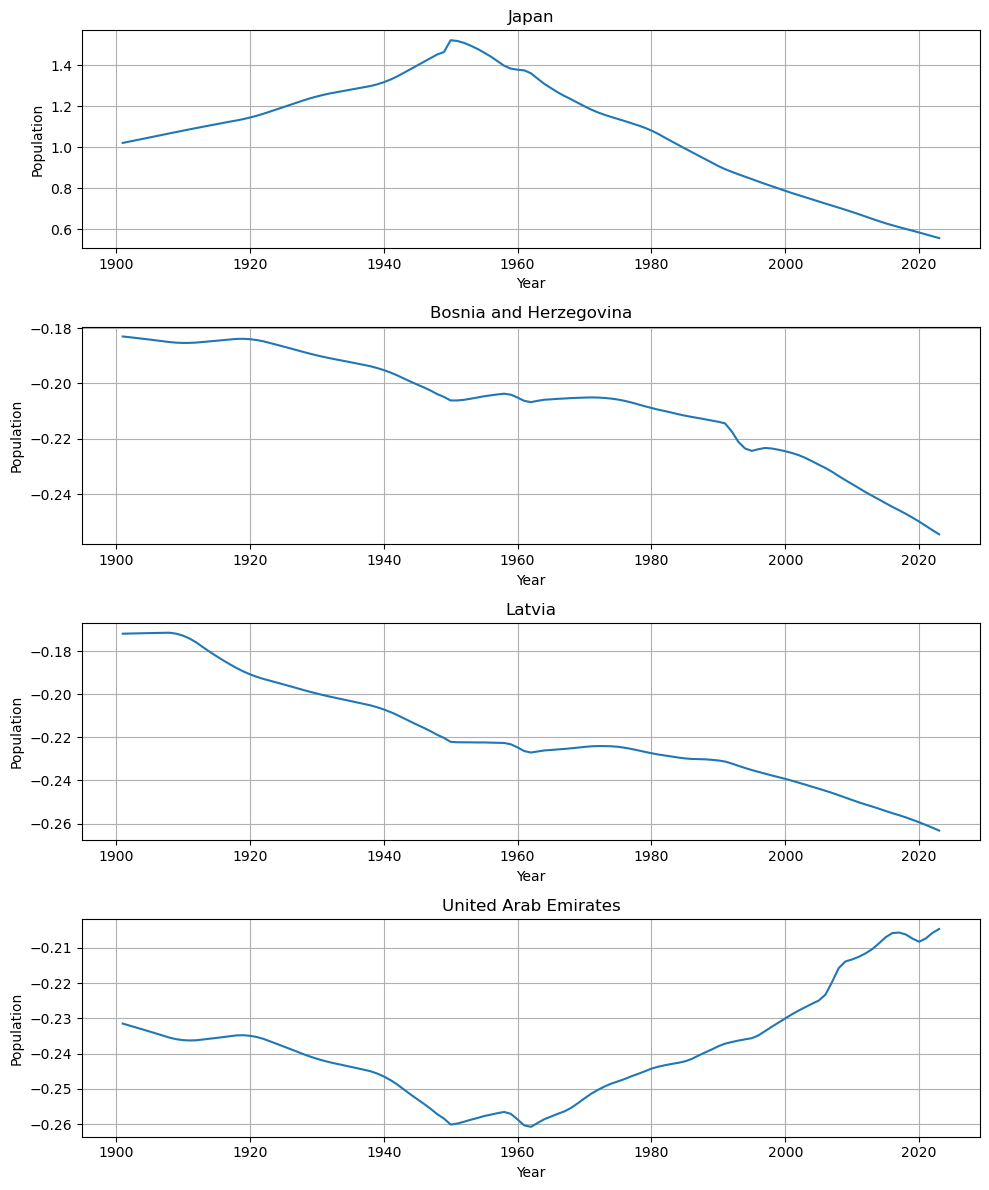

In [23]:
plot_countries(population_standardized, countries_to_plot)